# MTLR Synthetic Sweeps

This notebook collects the four main synthetic sweeps used in the paper:

- `delta` sweep to vary task relatedness itself.
- `epsilon` sweep under a fixed shared covariance design.
- `decay_alpha` sweep to control eigenvalue decay directly.
- `bar_b_target` sweep using a common-operator-norm spiked covariance family, where related tasks differ through directional mismatch rather than variance inflation.

The current synthetic DGP samples related tasks as `theta^* + delta u_j` and samples outlier tasks from an upper-hemisphere sphere with Euclidean radius `outlier_radius`.


In [1]:
from pathlib import Path
import sys


def _running_in_colab():
    try:
        import google.colab  # type: ignore  # noqa: F401
    except Exception:
        return False
    return True


if _running_in_colab():
    from google.colab import drive  # type: ignore
    drive.mount("/content/drive")

_code_candidates = [
    Path.cwd(),
    Path.cwd() / "MTLR_Codes",
    Path("/content/drive/MyDrive/Colab Notebooks/MTLR_Codes"),
    Path("/content/drive/My Drive/Colab Notebooks/MTLR_Codes"),
    Path("/content/drive/MyDrive/MTLR_Codes"),
    Path("/content/drive/My Drive/MTLR_Codes"),
]

CODE_DIR = None
for candidate in _code_candidates:
    if (candidate / "path_setup.py").exists():
        CODE_DIR = candidate.resolve()
        break

if CODE_DIR is None:
    raise FileNotFoundError(
        "Could not locate MTLR_Codes. In Colab, upload the folder to "
        "MyDrive/Colab Notebooks/MTLR_Codes."
    )

if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

from path_setup import setup_project_paths

CODE_DIR, PROJECT_ROOT, FIGURE_DIR = setup_project_paths(chdir=True)
print(f"CODE_DIR    : {CODE_DIR}")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"FIGURE_DIR  : {FIGURE_DIR}")

import importlib
from dataclasses import replace

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

import synthetic_sweeps as sr

# Reload the local helper module so notebook edits are picked up without a kernel restart.
importlib.reload(sr)

SyntheticSweepExperiment = sr.SyntheticSweepExperiment
SyntheticSetting = sr.SyntheticSetting
TrainingConfig = sr.TrainingConfig
format_summary_table = sr.format_summary_table
plot_split_panels = sr.plot_split_panels
run_synthetic_suite = sr.run_synthetic_suite
run_sweep = sr.run_sweep

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
plt.rcParams["figure.dpi"] = 130


Mounted at /content/drive
CODE_DIR    : /content/drive/MyDrive/Colab Notebooks/MTLR_Codes
PROJECT_ROOT: /content/drive/MyDrive/Colab Notebooks
FIGURE_DIR  : /content/drive/MyDrive/Colab Notebooks/MTLR_Codes/Images


## Presets

`TRAINING_FULL` uses 30 Monte Carlo repetitions with 5-fold CV, and it is the default setting for the four synthetic sweeps below.


In [2]:
BASE_SETTING = SyntheticSetting(
    n=100,
    m=30,
    d=30,
    delta=0.3,
    epsilon=0.1,
    outlier_radius=10.0,
    decay_alpha=1.0,
    effective_rank=30,
    covariance_mode="shared",
    covariance_groups=1,
    shared_theta_mode="axis",
    outlier_scale_mode="l2",
)

TRAINING_FULL = TrainingConfig(
    q_grid=(0.1, 0.4, 0.7, 1.0, 2.0, 4.0, 8.0, 16.0),
    n_fold=5,
    eta=0.05,
    t_iter=400,
    n_simul=30,
    seed0=1,
)

training = TRAINING_FULL
methods = ("DP", "ITL", "ARMUL", "OURS")

BASE_SETTING


SyntheticSetting(n=100, m=30, d=30, signal_norm=2.0, sigma=1.0, delta=0.3, epsilon=0.1, outlier_radius=10.0, decay_alpha=1.0, effective_rank=30, covariance_mode='shared', covariance_groups=1, shared_theta_mode='axis', outlier_scale_mode='l2', scaled_related_fraction=0.0, variance_multiplier=1.0, bar_b_target=None, inflated_related_count=0, deflated_related_count=None, deflate_all_remaining_related=False, shuffled_related_fraction=0.0, shuffle_offset=None, isotropic_related_count=0, isotropic_covariance_scale=1.0, spike_floor_ratio=0.05)

In [3]:
def show_summary(sim_df, summary_df, value_name, artifact_prefix=None):
    display(summary_df.round(4))

    for split in ("all", "related", "outlier"):
        display(Markdown(f"### {split.title()} MSE table"))
        display(format_summary_table(summary_df, value_name=value_name, split=split))

    fig, axes = plot_split_panels(summary_df, value_name=value_name, methods=methods)

    if artifact_prefix is not None:
        FIGURE_DIR.mkdir(parents=True, exist_ok=True)
        sim_df.to_csv(FIGURE_DIR / f"{artifact_prefix}_sim.csv", index=False)
        summary_df.to_csv(FIGURE_DIR / f"{artifact_prefix}_summary.csv", index=False)
        fig.savefig(FIGURE_DIR / f"{artifact_prefix}_panels.png", dpi=300, bbox_inches="tight")
        fig.savefig(FIGURE_DIR / f"{artifact_prefix}_panels.pdf", bbox_inches="tight")

    plt.show()


## 1. Sweep task relatedness $\delta$

This directly varies the inlier radius while keeping the contaminated multi-task setup fixed.


delta=0.2 (1/5)
delta=0.4 (2/5)
delta=0.8 (3/5)
delta=1.6 (4/5)
delta=3.2 (5/5)


,delta,method,balancedness_est_mean,all_mean,all_std,all_se,related_mean,related_std,related_se,outlier_mean,outlier_std,outlier_se,selected_q_mean
0,0.2,ARMUL,1.0,0.0420,0.0045,0.0008,0.0349,0.0049,0.0009,0.1051,0.0355,0.0065,0.1000
1,0.2,DP,1.0,0.0458,0.0055,0.0010,0.0372,0.0047,0.0009,0.1233,0.0590,0.0108,NaN
2,0.2,ITL,1.0,0.0442,0.0047,0.0009,0.0384,0.0043,0.0008,0.0960,0.0291,0.0053,NaN
3,0.2,OURS,1.0,0.0139,0.0039,0.0007,0.0023,0.0018,0.0003,0.1183,0.0399,0.0073,14.2667
4,0.4,ARMUL,1.0,0.0429,0.0046,0.0008,0.0360,0.0050,0.0009,0.1048,0.0353,0.0064,0.1000
5,0.4,DP,1.0,0.0470,0.0055,0.0010,0.0385,0.0048,0.0009,0.1228,0.0585,0.0107,NaN
6,0.4,ITL,1.0,0.0452,0.0048,0.0009,0.0396,0.0044,0.0008,0.0960,0.0291,0.0053,NaN
7,0.4,OURS,1.0,0.0141,0.0040,0.0007,0.0024,0.0018,0.0003,0.1194,0.0395,0.0072,13.4667
8,0.8,ARMUL,1.0,0.0450,0.0047,0.0009,0.0384,0.0051,0.0009,0.1044,0.0349,0.0064,0.1000
9,0.8,DP,1.0,0.0495,0.0055,0.0010,0.0414,0.0049,0.0009,0.1219,0.0575,0.0105,NaN


### All MSE table

method,delta,ARMUL,DP,ITL,OURS,B_emp
0,0.2,0.0420 +/- 0.0045,0.0458 +/- 0.0055,0.0442 +/- 0.0047,0.0139 +/- 0.0039,1.0
1,0.4,0.0429 +/- 0.0046,0.0470 +/- 0.0055,0.0452 +/- 0.0048,0.0141 +/- 0.0040,1.0
2,0.8,0.0450 +/- 0.0047,0.0495 +/- 0.0055,0.0475 +/- 0.0050,0.0147 +/- 0.0043,1.0
3,1.6,0.0498 +/- 0.0051,0.0557 +/- 0.0057,0.0527 +/- 0.0054,0.0169 +/- 0.0043,1.0
4,3.2,0.0619 +/- 0.0060,0.0729 +/- 0.0069,0.0664 +/- 0.0066,0.0260 +/- 0.0049,1.0


### Related MSE table

method,delta,ARMUL,DP,ITL,OURS,B_emp
0,0.2,0.0349 +/- 0.0049,0.0372 +/- 0.0047,0.0384 +/- 0.0043,0.0023 +/- 0.0018,1.0
1,0.4,0.0360 +/- 0.0050,0.0385 +/- 0.0048,0.0396 +/- 0.0044,0.0024 +/- 0.0018,1.0
2,0.8,0.0384 +/- 0.0051,0.0414 +/- 0.0049,0.0421 +/- 0.0045,0.0029 +/- 0.0016,1.0
3,1.6,0.0438 +/- 0.0055,0.0486 +/- 0.0051,0.0479 +/- 0.0049,0.0049 +/- 0.0013,1.0
4,3.2,0.0574 +/- 0.0064,0.0680 +/- 0.0064,0.0631 +/- 0.0062,0.0137 +/- 0.0020,1.0


### Outlier MSE table

method,delta,ARMUL,DP,ITL,OURS,B_emp
0,0.2,0.1051 +/- 0.0355,0.1233 +/- 0.0590,0.0960 +/- 0.0291,0.1183 +/- 0.0399,1.0
1,0.4,0.1048 +/- 0.0353,0.1228 +/- 0.0585,0.0960 +/- 0.0291,0.1194 +/- 0.0395,1.0
2,0.8,0.1044 +/- 0.0349,0.1219 +/- 0.0575,0.0960 +/- 0.0291,0.1212 +/- 0.0402,1.0
3,1.6,0.1035 +/- 0.0343,0.1202 +/- 0.0556,0.0960 +/- 0.0291,0.1257 +/- 0.0415,1.0
4,3.2,0.1021 +/- 0.0330,0.1172 +/- 0.0521,0.0960 +/- 0.0291,0.1365 +/- 0.0456,1.0


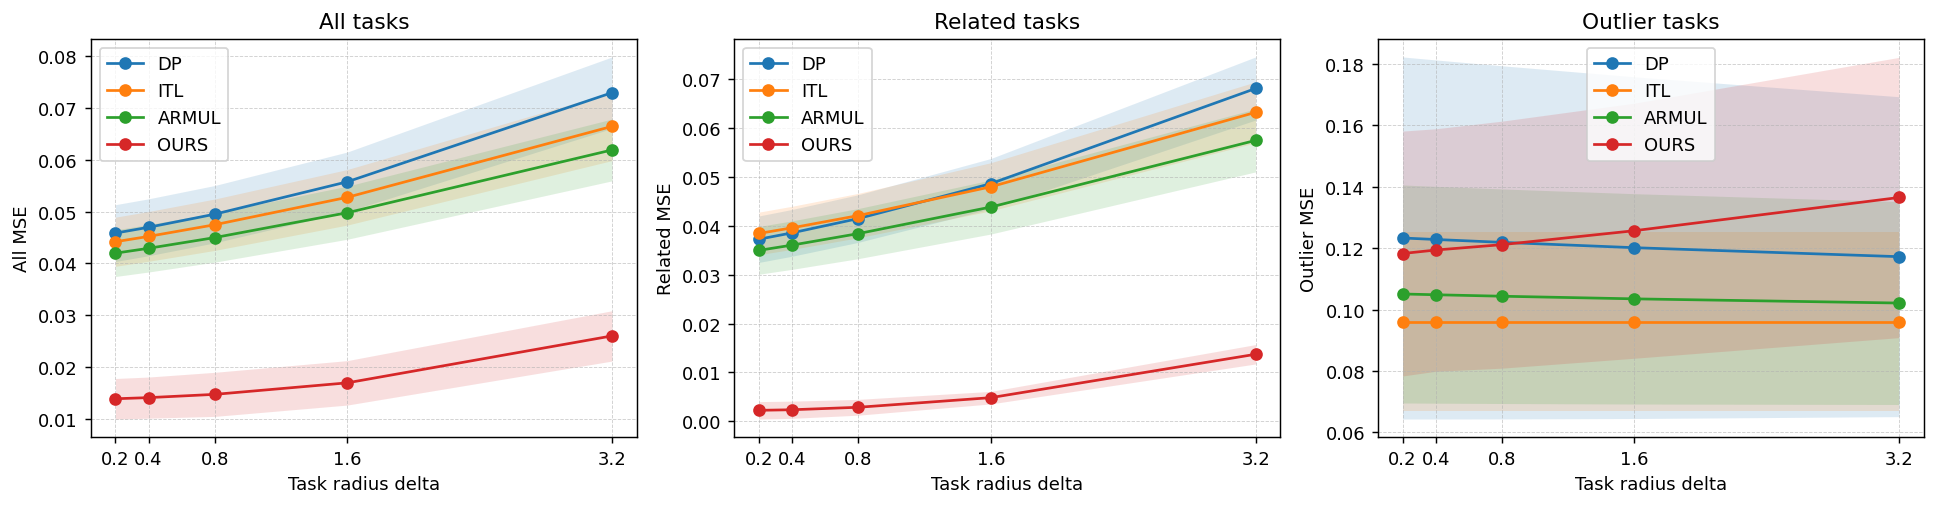

In [ ]:
delta_values = (0.2, 0.4, 0.8, 1.6, 3.2)

delta_sim, delta_summary = run_sweep(
    value_name="delta",
    values=delta_values,
    base_setting=replace(BASE_SETTING, covariance_mode="shared", covariance_groups=1, epsilon=0.1),
    training=training,
    methods=methods,
    verbose=True,
)

show_summary(delta_sim, delta_summary, value_name="delta", artifact_prefix="synthetic_delta")

## 2. Sweep the outlier fraction $\epsilon$

This varies the contamination level directly, using positive outlier fractions up to `epsilon=0.4`.


epsilon=0.05 (1/5)
epsilon=0.1 (2/5)
epsilon=0.2 (3/5)
epsilon=0.3 (4/5)
epsilon=0.4 (5/5)


,epsilon,method,balancedness_est_mean,all_mean,all_std,all_se,related_mean,related_std,related_se,outlier_mean,outlier_std,outlier_se,selected_q_mean
0,0.05,ARMUL,1.0,0.0385,0.0043,0.0008,0.0361,0.0037,0.0007,0.1072,0.0727,0.0133,0.1000
1,0.05,DP,1.0,0.0413,0.0045,0.0008,0.0383,0.0034,0.0006,0.1279,0.1144,0.0209,NaN
2,0.05,ITL,1.0,0.0428,0.0041,0.0007,0.0411,0.0036,0.0007,0.0922,0.0661,0.0121,NaN
3,0.05,OURS,1.0,0.0063,0.0031,0.0006,0.0018,0.0015,0.0003,0.1362,0.0843,0.0154,14.6667
4,0.10,ARMUL,1.0,0.0424,0.0045,0.0008,0.0355,0.0049,0.0009,0.1050,0.0354,0.0065,0.1000
5,0.10,DP,1.0,0.0464,0.0055,0.0010,0.0379,0.0048,0.0009,0.1231,0.0587,0.0107,NaN
6,0.10,ITL,1.0,0.0447,0.0048,0.0009,0.0390,0.0044,0.0008,0.0960,0.0291,0.0053,NaN
7,0.10,OURS,1.0,0.0139,0.0039,0.0007,0.0023,0.0016,0.0003,0.1185,0.0393,0.0072,14.2667
8,0.20,ARMUL,1.0,0.0491,0.0054,0.0010,0.0374,0.0052,0.0010,0.0957,0.0231,0.0042,0.1200
9,0.20,DP,1.0,0.0546,0.0072,0.0013,0.0402,0.0051,0.0009,0.1122,0.0422,0.0077,NaN


### All MSE table

method,epsilon,ARMUL,DP,ITL,OURS,B_emp
0,0.05,0.0385 +/- 0.0043,0.0413 +/- 0.0045,0.0428 +/- 0.0041,0.0063 +/- 0.0031,1.0
1,0.10,0.0424 +/- 0.0045,0.0464 +/- 0.0055,0.0447 +/- 0.0048,0.0139 +/- 0.0039,1.0
2,0.20,0.0491 +/- 0.0054,0.0546 +/- 0.0072,0.0489 +/- 0.0049,0.0234 +/- 0.0057,1.0
3,0.30,0.0577 +/- 0.0072,0.0661 +/- 0.0093,0.0552 +/- 0.0068,0.0356 +/- 0.0060,1.0
4,0.40,0.0642 +/- 0.0068,0.0743 +/- 0.0100,0.0595 +/- 0.0074,0.0459 +/- 0.0074,1.0


### Related MSE table

method,epsilon,ARMUL,DP,ITL,OURS,B_emp
0,0.05,0.0361 +/- 0.0037,0.0383 +/- 0.0034,0.0411 +/- 0.0036,0.0018 +/- 0.0015,1.0
1,0.10,0.0355 +/- 0.0049,0.0379 +/- 0.0048,0.0390 +/- 0.0044,0.0023 +/- 0.0016,1.0
2,0.20,0.0374 +/- 0.0052,0.0402 +/- 0.0051,0.0394 +/- 0.0040,0.0024 +/- 0.0018,1.0
3,0.30,0.0392 +/- 0.0056,0.0414 +/- 0.0060,0.0399 +/- 0.0046,0.0035 +/- 0.0030,1.0
4,0.40,0.0419 +/- 0.0042,0.0452 +/- 0.0043,0.0405 +/- 0.0051,0.0061 +/- 0.0055,1.0


### Outlier MSE table

method,epsilon,ARMUL,DP,ITL,OURS,B_emp
0,0.05,0.1072 +/- 0.0727,0.1279 +/- 0.1144,0.0922 +/- 0.0661,0.1362 +/- 0.0843,1.0
1,0.10,0.1050 +/- 0.0354,0.1231 +/- 0.0587,0.0960 +/- 0.0291,0.1185 +/- 0.0393,1.0
2,0.20,0.0957 +/- 0.0231,0.1122 +/- 0.0422,0.0871 +/- 0.0202,0.1075 +/- 0.0286,1.0
3,0.30,0.1010 +/- 0.0206,0.1237 +/- 0.0343,0.0909 +/- 0.0173,0.1103 +/- 0.0189,1.0
4,0.40,0.0978 +/- 0.0155,0.1181 +/- 0.0274,0.0879 +/- 0.0138,0.1055 +/- 0.0176,1.0


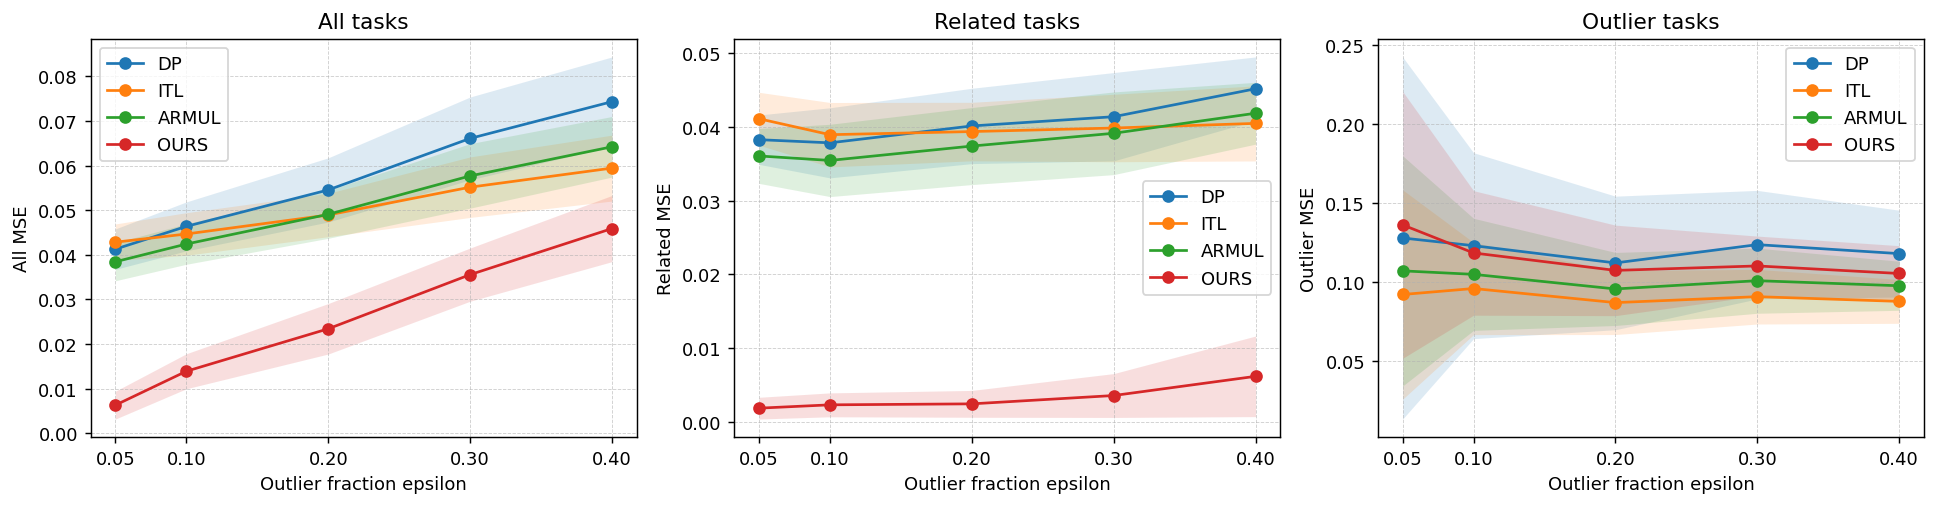

In [ ]:
epsilon_values = (0.05, 0.1, 0.2, 0.3, 0.4)

epsilon_sim, epsilon_summary = run_sweep(
    value_name="epsilon",
    values=epsilon_values,
    base_setting=replace(BASE_SETTING, covariance_mode="shared", covariance_groups=1),
    training=training,
    methods=methods,
    verbose=True,
)

show_summary(epsilon_sim, epsilon_summary, value_name="epsilon", artifact_prefix="synthetic_epsilon")

## 3. Sweep eigenvalue decay

Here `decay_alpha=0` means no decay, while larger values produce faster eigendecay under the same multi-task contamination setting.


decay_alpha=0.0 (1/5)
decay_alpha=0.5 (2/5)
decay_alpha=1.0 (3/5)
decay_alpha=1.5 (4/5)
decay_alpha=2.0 (5/5)


,decay_alpha,method,balancedness_est_mean,all_mean,all_std,all_se,related_mean,related_std,related_se,outlier_mean,outlier_std,outlier_se,selected_q_mean
0,0.0,ARMUL,1.0,0.1746,0.0106,0.0019,0.0496,0.0047,0.0009,1.2996,0.1085,0.0198,0.1000
1,0.0,DP,1.0,0.3583,0.0082,0.0015,0.0464,0.0057,0.0010,3.1654,0.0556,0.0102,NaN
2,0.0,ITL,1.0,0.2113,0.0099,0.0018,0.1087,0.0058,0.0011,1.1350,0.0971,0.0177,NaN
3,0.0,OURS,1.0,0.0656,0.0092,0.0017,0.0180,0.0030,0.0006,0.4941,0.0851,0.0155,1.0000
4,0.5,ARMUL,1.0,0.0648,0.0051,0.0009,0.0346,0.0050,0.0009,0.3370,0.0356,0.0065,0.1000
5,0.5,DP,1.0,0.0727,0.0059,0.0011,0.0382,0.0047,0.0009,0.3828,0.0614,0.0112,NaN
6,0.5,ITL,1.0,0.0670,0.0048,0.0009,0.0415,0.0044,0.0008,0.2963,0.0293,0.0053,NaN
7,0.5,OURS,1.0,0.0352,0.0052,0.0010,0.0129,0.0036,0.0007,0.2359,0.0622,0.0114,3.0000
8,1.0,ARMUL,1.0,0.0424,0.0045,0.0008,0.0355,0.0049,0.0009,0.1050,0.0354,0.0065,0.1000
9,1.0,DP,1.0,0.0464,0.0055,0.0010,0.0379,0.0048,0.0009,0.1231,0.0587,0.0107,NaN


### All MSE table

method,decay_alpha,ARMUL,DP,ITL,OURS,B_emp
0,0.0,0.1746 +/- 0.0106,0.3583 +/- 0.0082,0.2113 +/- 0.0099,0.0656 +/- 0.0092,1.0
1,0.5,0.0648 +/- 0.0051,0.0727 +/- 0.0059,0.0670 +/- 0.0048,0.0352 +/- 0.0052,1.0
2,1.0,0.0424 +/- 0.0045,0.0464 +/- 0.0055,0.0447 +/- 0.0048,0.0139 +/- 0.0039,1.0
3,1.5,0.0381 +/- 0.0044,0.0417 +/- 0.0054,0.0406 +/- 0.0048,0.0087 +/- 0.0036,1.0
4,2.0,0.0368 +/- 0.0043,0.0403 +/- 0.0053,0.0393 +/- 0.0048,0.0073 +/- 0.0034,1.0


### Related MSE table

method,decay_alpha,ARMUL,DP,ITL,OURS,B_emp
0,0.0,0.0496 +/- 0.0047,0.0464 +/- 0.0057,0.1087 +/- 0.0058,0.0180 +/- 0.0030,1.0
1,0.5,0.0346 +/- 0.0050,0.0382 +/- 0.0047,0.0415 +/- 0.0044,0.0129 +/- 0.0036,1.0
2,1.0,0.0355 +/- 0.0049,0.0379 +/- 0.0048,0.0390 +/- 0.0044,0.0023 +/- 0.0016,1.0
3,1.5,0.0356 +/- 0.0049,0.0378 +/- 0.0048,0.0386 +/- 0.0044,0.0014 +/- 0.0014,1.0
4,2.0,0.0357 +/- 0.0049,0.0378 +/- 0.0048,0.0385 +/- 0.0044,0.0016 +/- 0.0015,1.0


### Outlier MSE table

method,decay_alpha,ARMUL,DP,ITL,OURS,B_emp
0,0.0,1.2996 +/- 0.1085,3.1654 +/- 0.0556,1.1350 +/- 0.0971,0.4941 +/- 0.0851,1.0
1,0.5,0.3370 +/- 0.0356,0.3828 +/- 0.0614,0.2963 +/- 0.0293,0.2359 +/- 0.0622,1.0
2,1.0,0.1050 +/- 0.0354,0.1231 +/- 0.0587,0.0960 +/- 0.0291,0.1185 +/- 0.0393,1.0
3,1.5,0.0602 +/- 0.0334,0.0767 +/- 0.0567,0.0581 +/- 0.0286,0.0745 +/- 0.0351,1.0
4,2.0,0.0464 +/- 0.0323,0.0626 +/- 0.0556,0.0459 +/- 0.0280,0.0590 +/- 0.0327,1.0


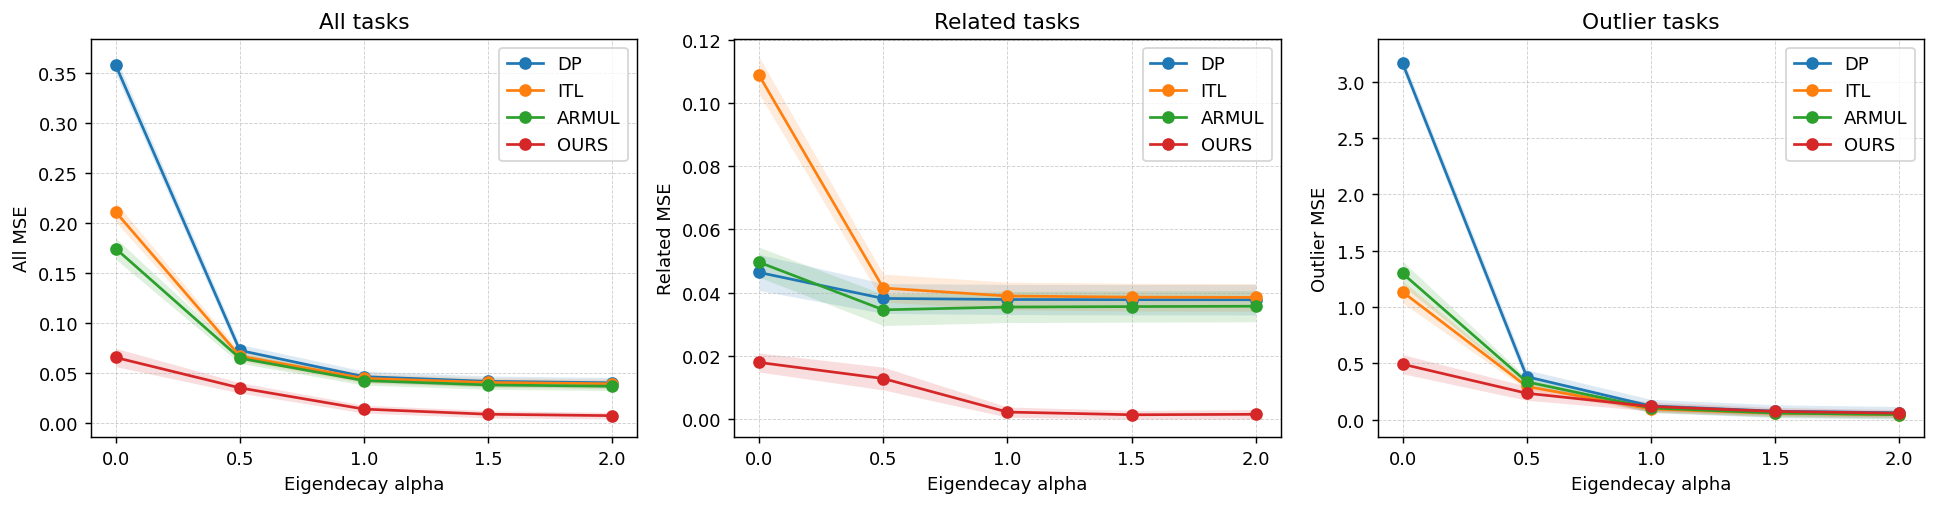

In [ ]:
decay_values = (0.0, 0.5, 1.0, 1.5, 2.0)

decay_sim, decay_summary = run_sweep(
    value_name="decay_alpha",
    values=decay_values,
    base_setting=replace(BASE_SETTING, epsilon=0.1, effective_rank=30, covariance_mode="shared"),
    training=training,
    methods=methods,
    verbose=True,
)

show_summary(decay_sim, decay_summary, value_name="decay_alpha", artifact_prefix="synthetic_decay_alpha")

## 4. Sweep population balancedness $\bar{B}$

We use a two-group spiked covariance family with a shared operator norm. Each related task has covariance of the form $\eta I + (1-\eta)e_{g(j)}e_{g(j)}^\top$, so $\bar{B}$ is driven by directional mismatch rather than by inflating $\|\Sigma_j\|_{\mathrm{op}}$.

For this section only, we increase the task count to $m=50$ and set $\epsilon=0.5$, so the sweep probes a harsher contamination regime while varying $\bar{B} \in \{5,10,15,20\}$.

For each target value, we calibrate the minority-group size and isotropic floor so that the population construction matches the requested $\bar{B}$ while keeping all related-task operator norms fixed. The summary tables report the realized empirical `B_emp` estimate from the generated design.


bar_b_target=5 (1/4)
bar_b_target=10 (2/4)
bar_b_target=15 (3/4)
bar_b_target=20 (4/4)


,bar_b_target,method,balancedness_est_mean,all_mean,all_std,all_se,related_mean,related_std,related_se,outlier_mean,outlier_std,outlier_se,selected_q_mean
0,5,ARMUL,5.0,0.0260,0.0059,0.0011,0.0021,0.0017,0.0003,0.0500,0.0120,0.0022,0.1000
1,5,DP,5.0,0.0362,0.0090,0.0017,0.0022,0.0016,0.0003,0.0701,0.0179,0.0033,NaN
2,5,ITL,5.0,0.0175,0.0038,0.0007,0.0043,0.0024,0.0004,0.0306,0.0081,0.0015,NaN
3,5,OURS,5.0,0.0074,0.0018,0.0003,0.0065,0.0023,0.0004,0.0083,0.0024,0.0004,0.1000
4,10,ARMUL,10.0,0.0635,0.0065,0.0012,0.0045,0.0011,0.0002,0.1224,0.0126,0.0023,0.1000
5,10,DP,10.0,0.0759,0.0110,0.0020,0.0048,0.0012,0.0002,0.1469,0.0215,0.0039,NaN
6,10,ITL,10.0,0.0539,0.0049,0.0009,0.0063,0.0017,0.0003,0.1015,0.0095,0.0017,NaN
7,10,OURS,10.0,0.0624,0.0057,0.0010,0.0194,0.0060,0.0011,0.1054,0.0091,0.0017,4.4667
8,15,ARMUL,15.0,0.0700,0.0040,0.0007,0.0046,0.0010,0.0002,0.1354,0.0081,0.0015,0.1000
9,15,DP,15.0,0.0811,0.0085,0.0016,0.0047,0.0010,0.0002,0.1575,0.0172,0.0031,NaN


### All MSE table

method,bar_b_target,ARMUL,DP,ITL,OURS,B_emp
0,5,0.0260 +/- 0.0059,0.0362 +/- 0.0090,0.0175 +/- 0.0038,0.0074 +/- 0.0018,5.0
1,10,0.0635 +/- 0.0065,0.0759 +/- 0.0110,0.0539 +/- 0.0049,0.0624 +/- 0.0057,10.0
2,15,0.0700 +/- 0.0040,0.0811 +/- 0.0085,0.0622 +/- 0.0035,0.0655 +/- 0.0047,15.0
3,20,0.0413 +/- 0.0043,0.0519 +/- 0.0088,0.0343 +/- 0.0037,0.0433 +/- 0.0049,20.0


### Related MSE table

method,bar_b_target,ARMUL,DP,ITL,OURS,B_emp
0,5,0.0021 +/- 0.0017,0.0022 +/- 0.0016,0.0043 +/- 0.0024,0.0065 +/- 0.0023,5.0
1,10,0.0045 +/- 0.0011,0.0048 +/- 0.0012,0.0063 +/- 0.0017,0.0194 +/- 0.0060,10.0
2,15,0.0046 +/- 0.0010,0.0047 +/- 0.0010,0.0077 +/- 0.0021,0.0185 +/- 0.0048,15.0
3,20,0.0023 +/- 0.0010,0.0024 +/- 0.0010,0.0054 +/- 0.0022,0.0150 +/- 0.0059,20.0


### Outlier MSE table

method,bar_b_target,ARMUL,DP,ITL,OURS,B_emp
0,5,0.0500 +/- 0.0120,0.0701 +/- 0.0179,0.0306 +/- 0.0081,0.0083 +/- 0.0024,5.0
1,10,0.1224 +/- 0.0126,0.1469 +/- 0.0215,0.1015 +/- 0.0095,0.1054 +/- 0.0091,10.0
2,15,0.1354 +/- 0.0081,0.1575 +/- 0.0172,0.1167 +/- 0.0066,0.1125 +/- 0.0087,15.0
3,20,0.0803 +/- 0.0087,0.1015 +/- 0.0177,0.0632 +/- 0.0070,0.0716 +/- 0.0080,20.0


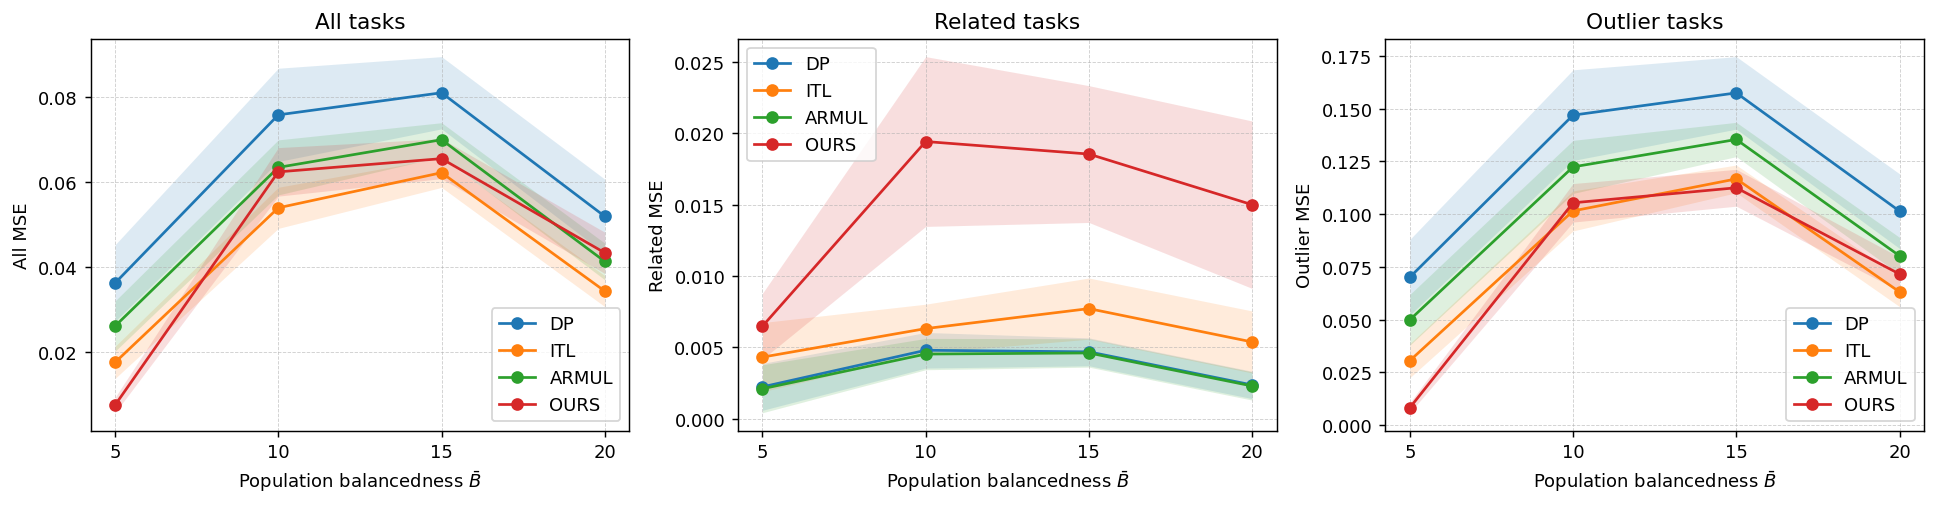

In [ ]:
bar_b_values = (5,10,15,20)


bar_b_sim, bar_b_summary = run_sweep(
    value_name="bar_b_target",
    values=bar_b_values,
    base_setting=replace(
        BASE_SETTING,
        m=50,
        covariance_mode="balanced_spike_groups",
        bar_b_target=1.0,
        epsilon=0.5,
        delta=0.5,
        shared_theta_mode="dense",
        outlier_scale_mode="l2",
    ),
    training=training,
    methods=methods,
    verbose=True,
)

show_summary(bar_b_sim, bar_b_summary, value_name="bar_b_target", artifact_prefix="synthetic_bar_b_target")
